In [23]:
# TITANIC SURVIVAL PREDICTION - COMPLETE END-TO-END PROJECT
# Tools & Techniques for Data Science - Course Project
# Your Name & Roll Number here

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("All libraries imported successfully")

All libraries imported successfully


In [24]:
# a. LOAD THE DATA & BRIEF EXPLANATION
df = pd.read_csv('data/train.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
# Dataset description (for report)
print("=== TITANIC DATASET ===")
print("Rows: 891 | Columns: 12")
print("Target: Survived (0 = Died, 1 = Survived)")
print("This is the famous Kaggle Titanic competition dataset")
df.info()

=== TITANIC DATASET ===
Rows: 891 | Columns: 12
Target: Survived (0 = Died, 1 = Survived)
This is the famous Kaggle Titanic competition dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Overall Survival Rate: 38.38%
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


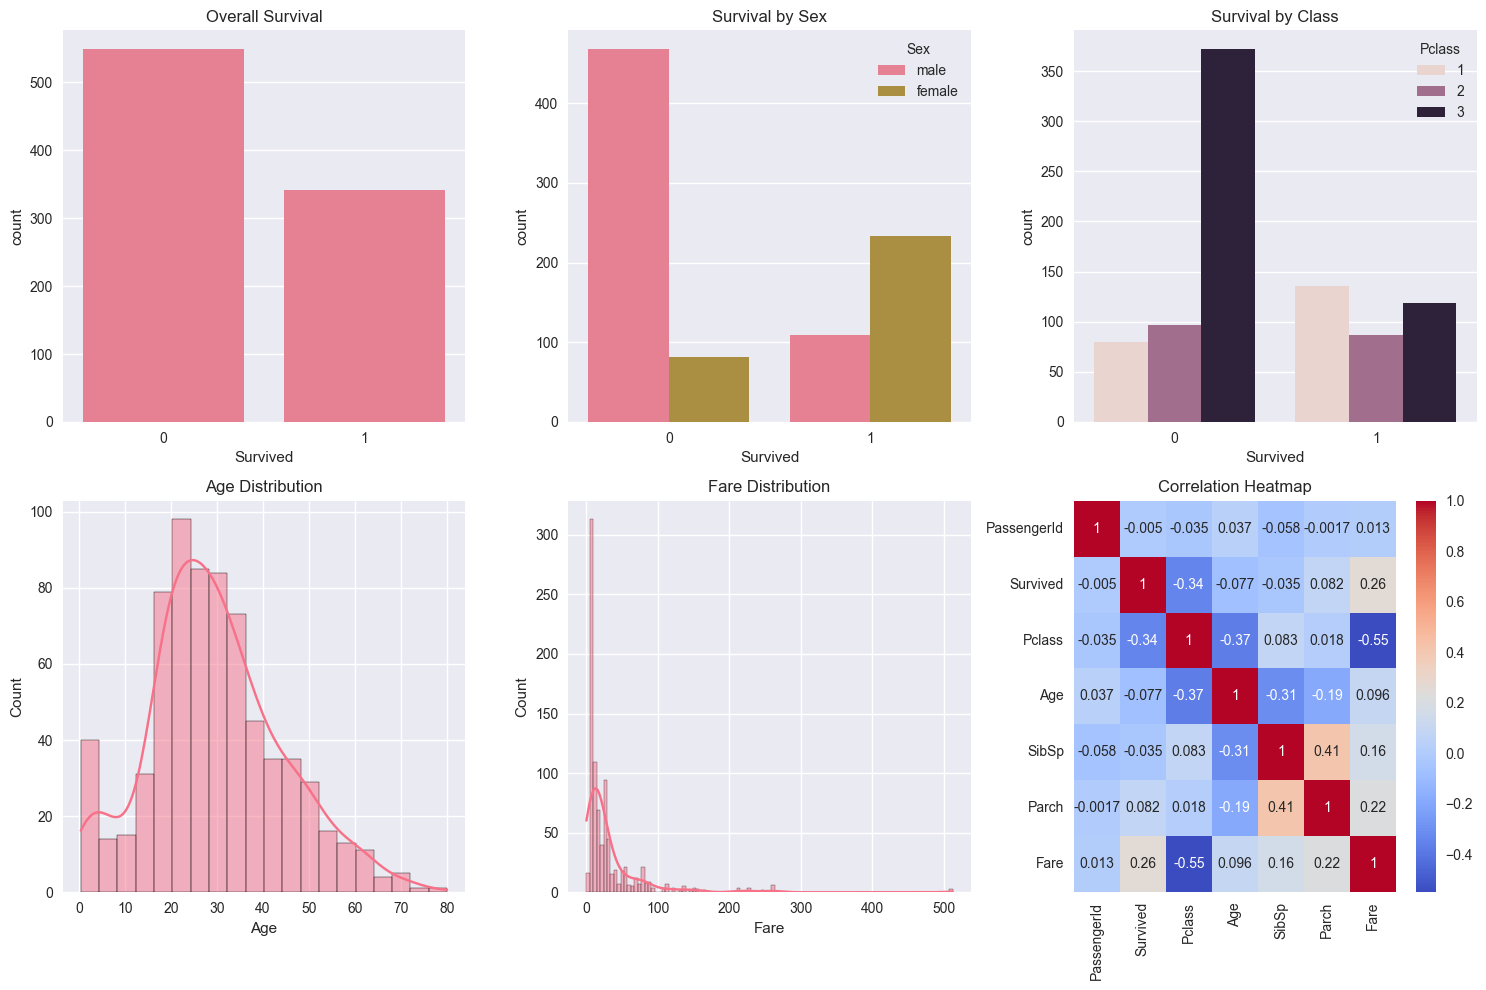

In [26]:
# b. EXPLORATORY DATA ANALYSIS (EDA)

# 1. Missing values
print("Missing Values:")
print(df.isnull().sum())

# 2. Survival rate
print(f"Overall Survival Rate: {df['Survived'].mean()*100:.2f}%")

# 3. Survival by Gender
print(df.groupby('Sex')['Survived'].mean())

# 4. Survival by Pclass
print(df.groupby('Pclass')['Survived'].mean())

# Visualizations
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
sns.countplot(x='Survived', data=df)
plt.title('Overall Survival')

plt.subplot(2,3,2)
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Sex')

plt.subplot(2,3,3)
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival by Class')

plt.subplot(2,3,4)
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Age Distribution')

plt.subplot(2,3,5)
sns.histplot(df['Fare'], kde=True)
plt.title('Fare Distribution')

plt.subplot(2,3,6)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [27]:
# c. DATA CLEANING & FEATURE ENGINEERING
# Make a copy
data = df.copy()
# 1. Extract Title from Name
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
data['Title'] = data['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
    'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
data['Title'] = data['Title'].replace('Mlle', 'Miss')
data['Title'] = data['Title'].replace('Ms', 'Miss')
data['Title'] = data['Title'].replace('Mme', 'Mrs')
# 2. Family Size & IsAlone
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
# 3. Fare per Person
data['FarePerPerson'] = data['Fare'] / data['FamilySize']
# 4. Age Group
data['AgeGroup'] = pd.cut(data['Age'], bins=[0,12,18,35,60,120], 
                          labels=['Child','Teen','YoungAdult','Adult','Senior'])
# 5. Fill missing values
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
# 6. Drop unnecessary columns
data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
print("Feature engineering completed!")
data.head()

Feature engineering completed!


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,FarePerPerson,AgeGroup
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,3.62500,YoungAdult
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,35.64165,Adult
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,7.92500,YoungAdult
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,26.55000,YoungAdult
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,8.05000,YoungAdult


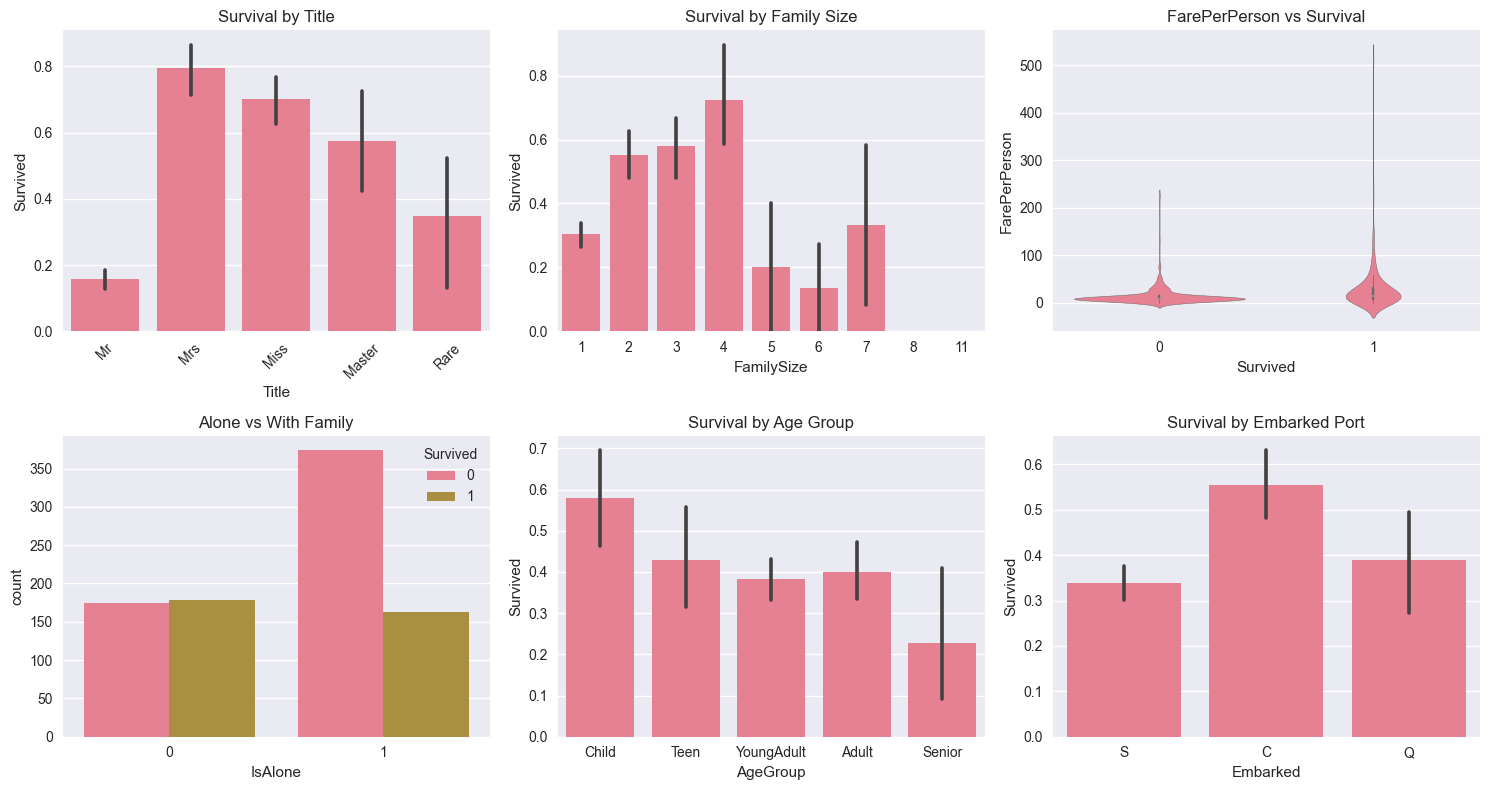

In [28]:
# More visualizations after cleaning
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
sns.barplot(x='Title', y='Survived', data=data)
plt.xticks(rotation=45)
plt.title('Survival by Title')

plt.subplot(2,3,2)
sns.barplot(x='FamilySize', y='Survived', data=data)
plt.title('Survival by Family Size')

plt.subplot(2,3,3)
sns.violinplot(x='Survived', y='FarePerPerson', data=data)
plt.title('FarePerPerson vs Survival')

plt.subplot(2,3,4)
sns.countplot(x='IsAlone', hue='Survived', data=data)
plt.title('Alone vs With Family')

plt.subplot(2,3,5)
sns.barplot(x='AgeGroup', y='Survived', data=data)
plt.title('Survival by Age Group')

plt.subplot(2,3,6)
sns.barplot(x='Embarked', y='Survived', data=data)
plt.title('Survival by Embarked Port')

plt.tight_layout()
plt.show()

In [29]:
# One-hot encoding
final_data = pd.get_dummies(data, columns=['Sex','Embarked','Pclass','Title','AgeGroup'], drop_first=True)

print("Final shape after encoding:", final_data.shape)
final_data.head()

Final shape after encoding: (891, 21)


,Survived,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,Sex_male,Embarked_Q,...,Pclass_2,Pclass_3,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_YoungAdult,AgeGroup_Adult,AgeGroup_Senior
0,0,22.0,1,0,7.2500,2,0,3.62500,True,False,...,False,True,False,True,False,False,False,True,False,False
1,1,38.0,1,0,71.2833,2,0,35.64165,False,False,...,False,False,False,False,True,False,False,False,True,False
2,1,26.0,0,0,7.9250,1,1,7.92500,False,False,...,False,True,True,False,False,False,False,True,False,False
3,1,35.0,1,0,53.1000,2,0,26.55000,False,False,...,False,False,False,False,True,False,False,True,False,False
4,0,35.0,0,0,8.0500,1,1,8.05000,True,False,...,False,True,False,True,False,False,False,True,False,False


In [30]:
# f. MACHINE LEARNING MODELS

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = final_data.drop('Survived', axis=1)
y = final_data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dictionary to store results
results = {}

In [ ]:
# 1. Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
pred = lr.predict(X_test_scaled)
results['Logistic Regression'] = accuracy_score(y_test, pred)
# 2. KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)
results['KNN'] = accuracy_score(y_test, pred)
# 3. Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred = dt.predict(X_test)
results['Decision Tree'] = accuracy_score(y_test, pred)
# 4. Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, pred)
# 5. XGBoost
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
results['XGBoost'] = accuracy_score(y_test, pred)
# Print results
print("MODEL ACCURACY COMPARISON")
for model, acc in results.items():
    print(f"{model}: {acc*100:.2f}%")

MODEL ACCURACY COMPARISON
Logistic Regression: 84.92%
KNN: 80.45%
Decision Tree: 81.01%
Random Forest: 79.89%
XGBoost: 82.68%


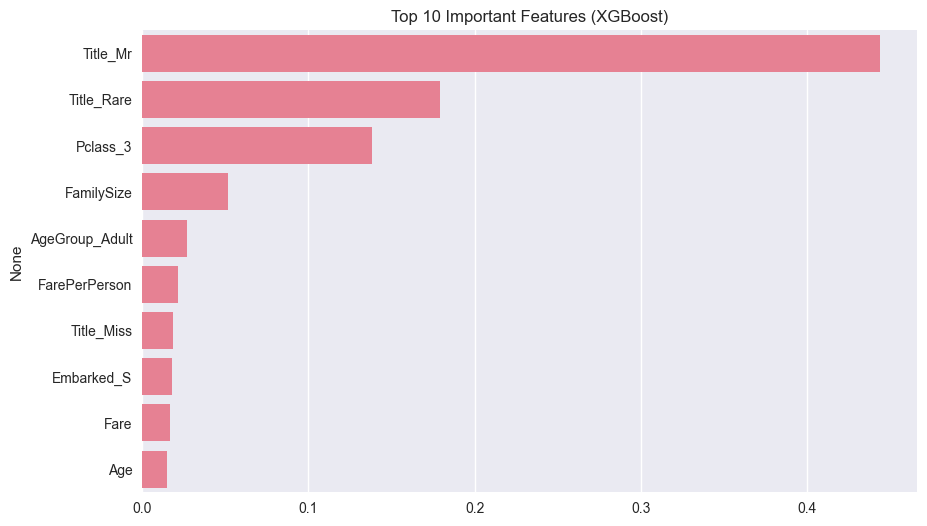

In [32]:
# Best model feature importance (XGBoost or Random Forest)
importances = xgb.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices][:10], y=feat_names[indices][:10])
plt.title('Top 10 Important Features (XGBoost)')
plt.show()

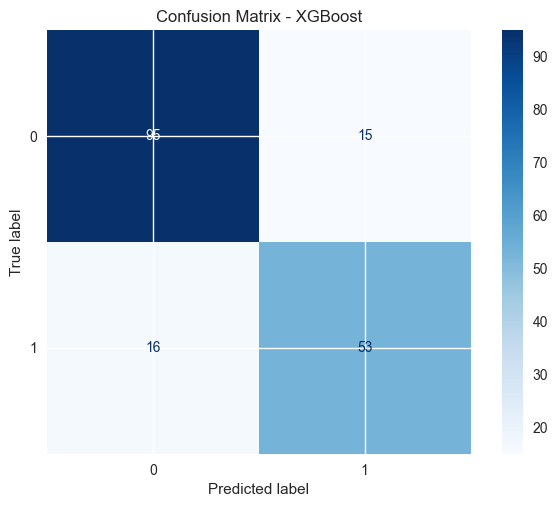

In [33]:
# Final confusion matrix of best model (XGBoost)
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, xgb.predict(X_test), cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.show()